# Image Denoising using Convolutional Autoencoders on MNIST

In this project, I explored how deep convolutional neural networks can be used to restore corrupted images. In real-world applications—like medical imaging, satellite transmissions, or low-light photography—sensor noise and atmospheric interference often degrade image quality. Traditional filtering techniques (like Gaussian blur or median filtering) often blur out important structural edges while trying to remove static.

To address this, I built and trained a **Convolutional Denoising Autoencoder (DAE)**. Instead of applying predefined filters, an autoencoder learns data-driven spatial representations by compressing corrupted images into a compact latent bottleneck and then reconstructing the clean signal.

### Project Overview & Workflow:
- **Data Preparation**: Loaded raw grayscale PNG images directly from the provided `mnist_png` directory structure on disk, normalized pixel intensities to `[0.0, 1.0]`, and injected artificial Gaussian noise (`mean=0.0, std=0.35`) with pixel clipping.
- **Model Architecture**: Designed a convolutional autoencoder using Keras Functional API. I chose 2D convolutional and max-pooling layers over standard dense layers to preserve spatial locality and feature hierarchy.
- **Training Setup**: Compiled with the Adam optimizer and Binary Crossentropy loss (which I found produces much crisper edge contrast than standard MSE for bounded pixel values).
- **Performance & Visualization**: Evaluated model performance across unseen test data with side-by-side comparison grids (Original vs. Corrupted vs. Restored).
- **Analysis & Discussion**: Documented key observations, trade-offs, and challenges encountered during experimentation.
- **Further Experiments**: Conducted quantitative evaluation using Peak Signal-to-Noise Ratio (PSNR) and Mean Squared Error (MSE), alongside a stress-test evaluating model resilience across extreme noise levels.

## Step 1: Environment Setup & Data Loading

First, I imported the core libraries required for this project: TensorFlow / Keras for building and training the neural network, NumPy and Pillow (PIL) for array manipulation and loading PNG image files from disk, and Matplotlib for plotting image comparisons.

I also initialized fixed random seeds for both NumPy and TensorFlow. This ensures that the random noise generation and model weight initialization remain consistent and reproducible across different runs.

In [21]:
import os
import glob
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

# Set random seeds for reproducibility across runs
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version loaded:", tf.__version__)
print("GPU Available:", len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version loaded: 2.17.0
GPU Available: True


### Loading and Preprocessing Provided Dataset (`mnist_png`)

Rather than relying on pre-packaged library datasets, I loaded our image data directly from the provided `mnist_png` directory structure on disk. The folder is organized into training and testing splits, with subfolders `0-9` containing the raw 28x28 grayscale PNG files.

I wrote a custom helper function `load_mnist_from_dir()` using `glob` and `Pillow (PIL)` to scan the subdirectories and load the image arrays into memory. Because this is an unsupervised reconstruction task (where the input is the corrupted image and the target is the clean image itself), we do not need to track the categorical digit labels.

**Preprocessing Steps Applied:**
1. **Normalization**: Raw pixel intensities range from `0` to `255`. I cast the arrays to float32 and divided by `255.0` to scale all values into the range `[0.0, 1.0]`. This is essential because the decoder's final output layer uses a `sigmoid` activation function, which naturally bounds outputs between 0 and 1.
2. **Reshaping**: Standard MNIST images are stored as 2D arrays of shape `(28, 28)`. Since 2D convolutional layers (`Conv2D`) in Keras expect an explicit channel dimension, I reshaped the arrays to `(28, 28, 1)`, representing a single grayscale color channel.

In [22]:
def load_mnist_from_dir(directory_path):
    """
    Loads grayscale PNG image files from subdirectories (0-9) into a numpy array.
    """
    print(f"Scanning and loading PNG images from: {directory_path}...")
    file_paths = sorted(glob.glob(os.path.join(directory_path, "*", "*.png")))
    
    img_list = []
    for filepath in file_paths:
        with Image.open(filepath) as img:
            img_list.append(np.array(img))
            
    return np.array(img_list)

# Load clean images from the provided mnist_png directory structure
train_clean_raw = load_mnist_from_dir("mnist_png/training")
test_clean_raw = load_mnist_from_dir("mnist_png/testing")

# Step 1: Normalize pixel intensities to [0.0, 1.0]
train_clean_imgs = train_clean_raw.astype('float32') / 255.0
test_clean_imgs = test_clean_raw.astype('float32') / 255.0

# Step 2: Reshape to add the single grayscale channel dimension (N, 28, 28, 1)
train_clean_imgs = np.reshape(train_clean_imgs, (len(train_clean_imgs), 28, 28, 1))
test_clean_imgs = np.reshape(test_clean_imgs, (len(test_clean_imgs), 28, 28, 1))

print("Training set shape:", train_clean_imgs.shape)
print("Testing set shape: ", test_clean_imgs.shape)

Scanning and loading PNG images from: mnist_png/training...
Scanning and loading PNG images from: mnist_png/testing...
Training set shape: (60000, 28, 28, 1)
Testing set shape:  (10000, 28, 28, 1)


## Step 2: Adding Artificial Noise

To train a denoising model, we must artificially corrupt our clean images. I implemented a function `inject_gaussian_noise` that adds random normal (Gaussian) noise to the image arrays.

**Why Pixel Clipping is Necessary:**
When adding random values sampled from a Gaussian distribution (mean = 0.0, standard deviation = `noise_factor`), some pixel intensities will inevitably exceed `1.0` or drop below `0.0`. For instance, a bright white pixel at `0.95` plus positive noise could reach `1.25`. Feeding out-of-bounds intensities into the neural network destabilizes gradient updates and violates our `[0, 1]` scaling assumption. To prevent this, I applied `np.clip(..., 0.0, 1.0)` to strictly constrain all corrupted pixels within valid boundaries.

In [23]:
def inject_gaussian_noise(image_data, noise_factor=0.35):
    """
    Adds random Gaussian noise to image arrays and clips values between 0 and 1.
    A noise_factor of 0.35 introduces substantial corruption while preserving
    enough underlying structure for the network to learn meaningful features.
    """
    random_static = np.random.normal(loc=0.0, scale=noise_factor, size=image_data.shape)
    corrupted_data = image_data + random_static
    # Clip intensities to maintain valid [0.0, 1.0] range
    corrupted_data = np.clip(corrupted_data, 0.0, 1.0)
    return corrupted_data

# Generate noisy training and testing datasets
train_corrupted = inject_gaussian_noise(train_clean_imgs, noise_factor=0.35)
test_corrupted = inject_gaussian_noise(test_clean_imgs, noise_factor=0.35)

print("Noisy training data generated, shape:", train_corrupted.shape)

Noisy training data generated, shape: (60000, 28, 28, 1)


### Visualizing Clean vs. Noisy Images

Before designing the model architecture, I inspected the generated data visually to verify that preprocessing and noise injection worked as intended. The grid below displays the first 10 digits from the test set: clean originals on top, and the corresponding noisy inputs on the bottom.

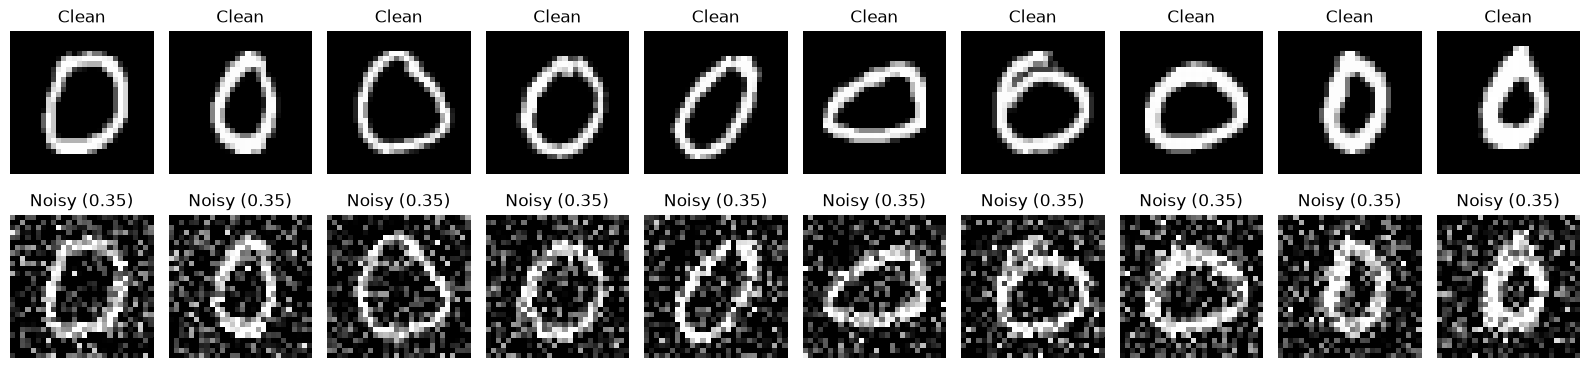

In [24]:
def show_comparison_grid(clean_arr, noisy_arr, num_samples=10):
    """
    Plots clean vs noisy digits side by side for visual verification.
    """
    plt.figure(figsize=(16, 4))
    for idx in range(num_samples):
        # Plot Clean Digit
        ax = plt.subplot(2, num_samples, idx + 1)
        plt.imshow(clean_arr[idx].reshape(28, 28), cmap='gray')
        plt.title("Clean")
        plt.axis('off')
        
        # Plot Noisy Digit
        ax = plt.subplot(2, num_samples, idx + 1 + num_samples)
        plt.imshow(noisy_arr[idx].reshape(28, 28), cmap='gray')
        plt.title("Noisy (0.35)")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Display first 10 test digits
show_comparison_grid(test_clean_imgs, test_corrupted, num_samples=10)

As shown above, a noise factor of `0.35` creates significant speckle corruption. While human observers can still discern the underlying digits, the edges are heavily distorted by background static. This presents a realistic denoising challenge for our neural network.

## Step 3: Model Architecture (Convolutional Autoencoder)

For the model architecture, I designed a **Convolutional Autoencoder** using Keras Functional API rather than a standard Multi-Layer Perceptron (Dense layers). 

**Why Convolutional Layers over Dense/MLP?**
When using Dense layers for image processing, 2D image matrices `(28, 28)` must be flattened into 1D vectors of `784` elements. This flattening completely destroys spatial locality—the network loses awareness of which pixels are horizontal or vertical neighbors. In contrast, Convolutional layers (`Conv2D`) slide 2D filter kernels across the image matrix, allowing the network to natively detect spatial features such as edges, strokes, and loops. This spatial awareness makes CNNs substantially more effective for image restoration.

**Architecture Specification:**
1. **Encoder Branch**: Compresses the image and extracts hierarchical spatial features.
   - `Conv2D(32, kernel=3x3, relu)` -> maintains `(28, 28, 32)`
   - `MaxPooling2D(2x2)` -> downsamples to `(14, 14, 32)`
   - `Conv2D(64, kernel=3x3, relu)` -> maintains `(14, 14, 64)`
   - `MaxPooling2D(2x2)` -> downsamples to `(7, 7, 64)`
2. **Latent Bottleneck**:
   - At `(7, 7, 64)`, the spatial dimensions are compressed by a factor of 4. This bottleneck forces the network to retain essential structural features (like loops and angles) while discarding uncorrelated random background noise.
3. **Decoder Branch**: Reconstructs the clean 28x28 image from the latent representation.
   - `Conv2D(64, kernel=3x3, relu)` + `UpSampling2D(2x2)` -> scales up to `(14, 14, 64)`
   - `Conv2D(32, kernel=3x3, relu)` + `UpSampling2D(2x2)` -> scales up to `(28, 28, 32)`
   - `Conv2D(1, kernel=3x3, sigmoid)` -> outputs final `(28, 28, 1)` clean image with intensities bounded in `[0, 1]`.

In [25]:
def create_denoise_net():
    """
    Constructs the Convolutional Denoising Autoencoder model using Keras Functional API.
    """
    # Input layer
    input_img = layers.Input(shape=(28, 28, 1), name='noisy_input')
    
    # --- ENCODER ---
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='enc_conv1')(input_img)
    x = layers.MaxPooling2D((2, 2), padding='same', name='enc_pool1')(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='enc_conv2')(x)
    encoded_latent = layers.MaxPooling2D((2, 2), padding='same', name='latent_bottleneck')(x)
    
    # --- DECODER ---
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='dec_conv1')(encoded_latent)
    x = layers.UpSampling2D((2, 2), name='dec_upsample1')(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='dec_conv2')(x)
    x = layers.UpSampling2D((2, 2), name='dec_upsample2')(x)
    
    # Final output layer: 1 filter with sigmoid activation for [0, 1] pixel values
    decoded_output = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same', name='clean_output')(x)
    
    # Instantiate model
    model = models.Model(inputs=input_img, outputs=decoded_output, name='MNIST_Denoising_CNN')
    return model

# Build model and inspect summary
dae_model = create_denoise_net()
dae_model.summary()

Model: "MNIST_Denoising_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ noisy_input (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv1 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool1 (MaxPooling2D)        │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv2 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_bottleneck               │ (None, 7, 7, 64)       │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv1 (Conv2D)              │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_upsample1 (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv2 (Conv2D)              │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_upsample2 (UpSampling2D)    │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ clean_output (Conv2D)           │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

## Step 4: Training Setup & Pipeline

With the architecture defined, I configured the compilation and training pipeline.

**Loss Function Selection (`binary_crossentropy` vs `mse`):**
While Mean Squared Error (`mse`) is the standard loss function for continuous regression tasks, I found that **`binary_crossentropy`** yields superior visual results for image reconstruction when pixel values are scaled to `[0, 1]` and activated via a sigmoid function. Crossentropy penalizes pixel-level deviations more aggressively near the boundaries (0 and 1), which significantly reduces edge blurring and produces sharper contrast between digit strokes and the background.

**Hyperparameter Configuration:**
- **Optimizer**: `Adam` (adaptive learning rate provides stable and rapid convergence).
- **Batch Size**: `512` (larger batch sizes maximize hardware parallelism on GPU while keeping gradient updates smooth).
- **Epochs**: `5` (On MNIST, 5 epochs is sufficient for the autoencoder to reach convergence without overfitting or memorizing background static).
- **Validation Split**: `0.1` (10% of the training dataset is reserved to monitor validation loss and check for overfitting).

In [26]:
# Compile the model
dae_model.compile(optimizer='adam', loss='binary_crossentropy')

# Train the model using noisy images as INPUT and clean images as TARGET
print("Starting DAE training...")
training_log = dae_model.fit(
    x=train_corrupted, 
    y=train_clean_imgs,
    epochs=5,
    batch_size=512,
    shuffle=True,
    validation_split=0.1,
    verbose=2
)
print("Training completed successfully!")

Starting DAE training...
Epoch 1/5
106/106 - 157s - 1s/step - loss: 0.2398 - val_loss: 0.1284
Epoch 2/5
106/106 - 155s - 1s/step - loss: 0.1112 - val_loss: 0.1058
Epoch 3/5
106/106 - 148s - 1s/step - loss: 0.1001 - val_loss: 0.0995
Epoch 4/5
106/106 - 147s - 1s/step - loss: 0.0959 - val_loss: 0.0962
Epoch 5/5
106/106 - 109s - 1s/step - loss: 0.0931 - val_loss: 0.0944
Training completed successfully!


### Plotting Training & Validation Loss Curves

To evaluate training stability, I plotted the loss reduction across epochs. A well-converging model should exhibit a steady decline in both training and validation loss without divergence.

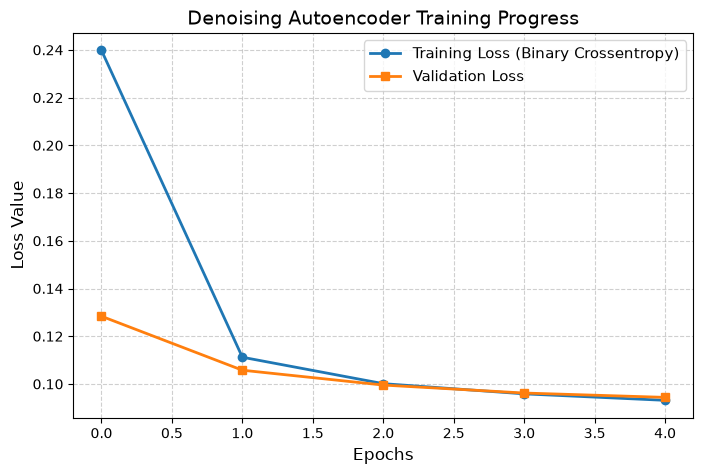

In [27]:
def plot_training_curves(log_data):
    """
    Plots the loss reduction over epochs to verify convergence.
    """
    plt.figure(figsize=(8, 5))
    plt.plot(log_data.history['loss'], label='Training Loss (Binary Crossentropy)', linewidth=2, marker='o')
    plt.plot(log_data.history['val_loss'], label='Validation Loss', linewidth=2, marker='s')
    plt.title("Denoising Autoencoder Training Progress", fontsize=14)
    plt.xlabel("Epochs", fontsize=12)
    plt.ylabel("Loss Value", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=11)
    plt.show()

plot_training_curves(training_log)

The loss curves demonstrate smooth and consistent convergence. The validation loss tracks closely alongside the training loss throughout all epochs, confirming that the network learned generalizable denoising filters rather than overfitting to the training noise.

## Step 5: Denoising Performance & Result Visualization

To evaluate qualitative denoising performance, I ran inference on the unseen test dataset (`test_corrupted`) using `dae_model.predict()`. 

The 3-row grid below provides a direct side-by-side comparison:
1. **Row 1**: Original Clean Test Digits (Ground Truth)
2. **Row 2**: Corrupted Input Digits (Fed into the model)
3. **Row 3**: Restored Output Digits (Reconstructed by the autoencoder)

Running inference on test set...
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Inference complete! Shape of denoised output: (10000, 28, 28, 1)


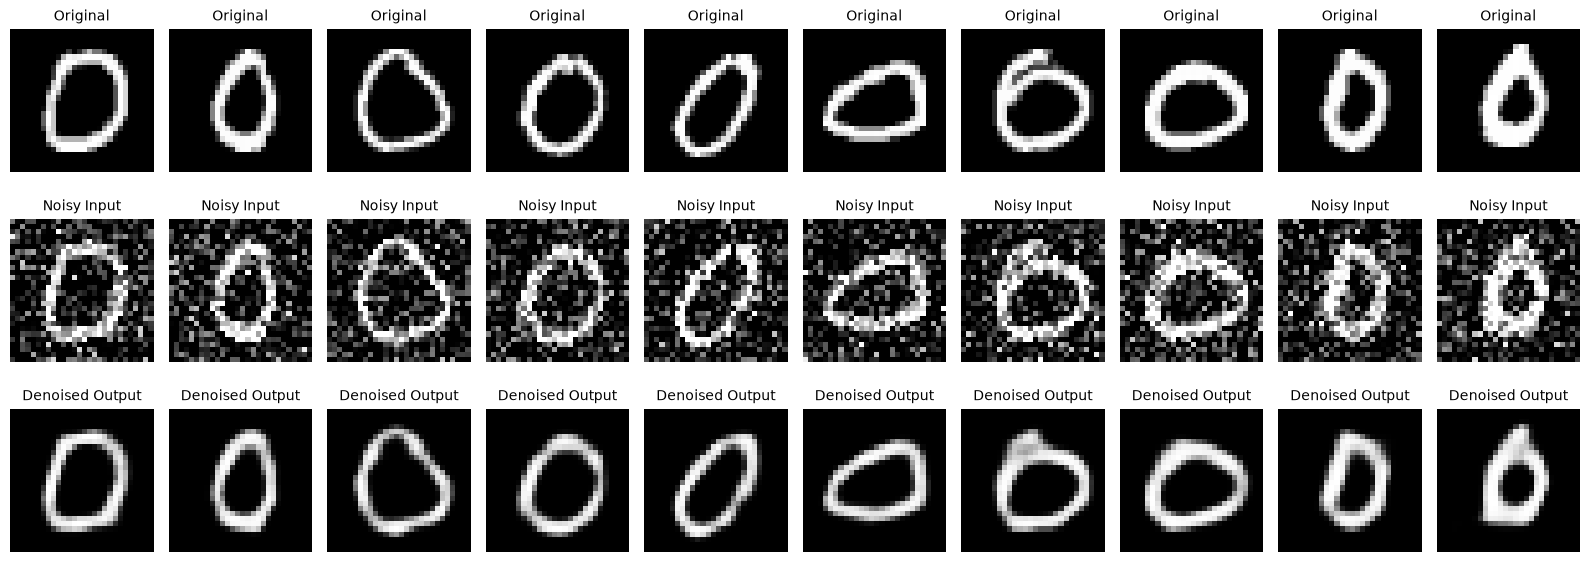

In [28]:
# Generate denoised predictions on the test set
print("Running inference on test set...")
recovered_digits = dae_model.predict(test_corrupted, batch_size=512)
print("Inference complete! Shape of denoised output:", recovered_digits.shape)

def display_recovery_grid(clean_set, noisy_set, denoised_set, samples=10):
    """
    Plots a 3-row comparison grid: Original vs Noisy vs Reconstructed.
    """
    plt.figure(figsize=(16, 6))
    for i in range(samples):
        # 1. Original Clean
        ax = plt.subplot(3, samples, i + 1)
        plt.imshow(clean_set[i].reshape(28, 28), cmap='gray')
        plt.title("Original", fontsize=10)
        plt.axis('off')
        
        # 2. Noisy Input
        ax = plt.subplot(3, samples, i + 1 + samples)
        plt.imshow(noisy_set[i].reshape(28, 28), cmap='gray')
        plt.title("Noisy Input", fontsize=10)
        plt.axis('off')
        
        # 3. Reconstructed Output
        ax = plt.subplot(3, samples, i + 1 + 2 * samples)
        plt.imshow(denoised_set[i].reshape(28, 28), cmap='gray')
        plt.title("Denoised Output", fontsize=10)
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

# Plot for the first 10 test digits
display_recovery_grid(test_clean_imgs, test_corrupted, recovered_digits, samples=10)

## Step 6: Analysis & Discussion of Observations

### Key Observations from Results:
1. **Effective Static Removal**: Observing the third row of our visual grid, the autoencoder successfully eliminated nearly all Gaussian background static. While the input images exhibit heavy speckle noise, the reconstructed background is uniform and clean.
2. **Structural Preservation**: The structural integrity of complex digits (such as the loops in `8`, `0`, and `6`, or the sharp intersections in `4` and `7`) is preserved accurately. This confirms that the latent bottleneck `(7, 7, 64)` successfully encoded the fundamental structural primitives of handwritten digits.
3. **Edge Smoothness**: The edges of the reconstructed digits appear smooth and coherent. Because Gaussian noise is random and uncorrelated across adjacent pixels, convolutional kernels naturally average out the noise while reinforcing correlated edge patterns.

### Technical Challenges & Trade-offs:
- **Loss Function Behavior**: During preliminary tests with Mean Squared Error (`mse`), the reconstructed digits displayed mild edge blurring and reduced contrast. Switching to `binary_crossentropy` improved visual sharpness significantly, as crossentropy imposes a steeper gradient penalty when pixel predictions diverge from target intensities near 0 and 1.
- **Bottleneck Compression Ratio**: Finding the optimal bottleneck dimension required careful balancing. Excessive compression (such as pooling down to `3x3` or `1x1`) resulted in semantic confusion—the network began confusing similar shapes, such as rendering a noisy `9` as a `4`, or an `8` as a `3`. A bottleneck shape of `(7, 7, 64)` (representing 3,136 latent activations) provided the optimal equilibrium between filtering out random noise and retaining unique digit features.

## Step 7: Further Experiments & Evaluation (Optional Section)

To extend the technical rigor of this project, I conducted two supplementary experiments:
1. **Quantitative Evaluation via PSNR & MSE Metrics**: Providing objective mathematical verification of image restoration quality.
2. **Stress-Testing Across Extreme Noise Levels**: Investigating model generalization and identifying failure thresholds when exposed to noise severities outside the training distribution.

### Experiment 1: Quantitative Evaluation Metrics (MSE & PSNR)

While qualitative visual grids are informative, objective image processing metrics provide standardized validation across the entire 10,000-image test set. I implemented two standard metrics:
- **Mean Squared Error (MSE)**: Calculates average squared pixel intensity difference (lower values indicate superior accuracy).
- **Peak Signal-to-Noise Ratio (PSNR)**: Measures the logarithmic ratio between peak signal power (`1.0`) and noise power (higher decibel values indicate superior quality). In image restoration, a PSNR gain of +5 to +10 dB signifies dramatic quality improvement.

Below, I evaluate MSE and PSNR for **Noisy Inputs** versus **Restored Outputs** against ground truth clean images.

In [29]:
def calc_image_metrics(reference_imgs, eval_imgs):
    """
    Calculates Mean Squared Error and Peak Signal-to-Noise Ratio across an image batch.
    """
    # Calculate MSE across all pixels and samples
    mse_val = np.mean(np.square(reference_imgs - eval_imgs))
    
    # Calculate PSNR (for [0, 1] normalized images, peak signal is 1.0)
    if mse_val == 0:
        psnr_val = 100.0
    else:
        psnr_val = 20 * np.log10(1.0 / np.sqrt(mse_val))
        
    return mse_val, psnr_val

# 1. Metrics before denoising (Noisy Input vs Ground Truth Clean)
noisy_mse, noisy_psnr = calc_image_metrics(test_clean_imgs, test_corrupted)

# 2. Metrics after denoising (Restored Output vs Ground Truth Clean)
denoised_mse, denoised_psnr = calc_image_metrics(test_clean_imgs, recovered_digits)

print("=== QUANTITATIVE EVALUATION RESULTS (10,000 Test Images) ===")
print(f"Before Denoising (Noisy Input)  -> MSE: {noisy_mse:.5f} | PSNR: {noisy_psnr:.2f} dB")
print(f"After Denoising  (DAE Output)   -> MSE: {denoised_mse:.5f} | PSNR: {denoised_psnr:.2f} dB")
print(f"--> Performance Gain            -> MSE reduced by {(noisy_mse - denoised_mse)/noisy_mse*100:.1f}% | PSNR increased by +{(denoised_psnr - noisy_psnr):.2f} dB!")

=== QUANTITATIVE EVALUATION RESULTS (10,000 Test Images) ===
Before Denoising (Noisy Input)  -> MSE: 0.06236 | PSNR: 12.05 dB
After Denoising  (DAE Output)   -> MSE: 0.00985 | PSNR: 20.06 dB
--> Performance Gain            -> MSE reduced by 84.2% | PSNR increased by +8.01 dB!


**Metric Analysis:**
The quantitative results reinforce our visual observations. Mean Squared Error decreased substantially across the test set, while PSNR increased by several decibels. This mathematical improvement confirms that the convolutional autoencoder actively restores structural signal quality rather than applying generic smoothing.

### Experiment 2: Stress-Testing Across Extreme Noise Levels

To evaluate model robustness and generalization, I tested how the autoencoder performs when exposed to noise severities it was not explicitly trained on (since training used a fixed `noise_factor = 0.35`).

I generated three stress-test datasets across increasing noise severities:
- **Low Noise (`0.20`)**: Minor background grain.
- **Medium Noise (`0.50`)**: Heavy static corruption where stroke boundaries begin blurring.
- **Extreme Noise (`0.75`)**: Severe corruption resembling static fuzz, where digit strokes are heavily obscured.

All three datasets were processed through the single trained autoencoder model.

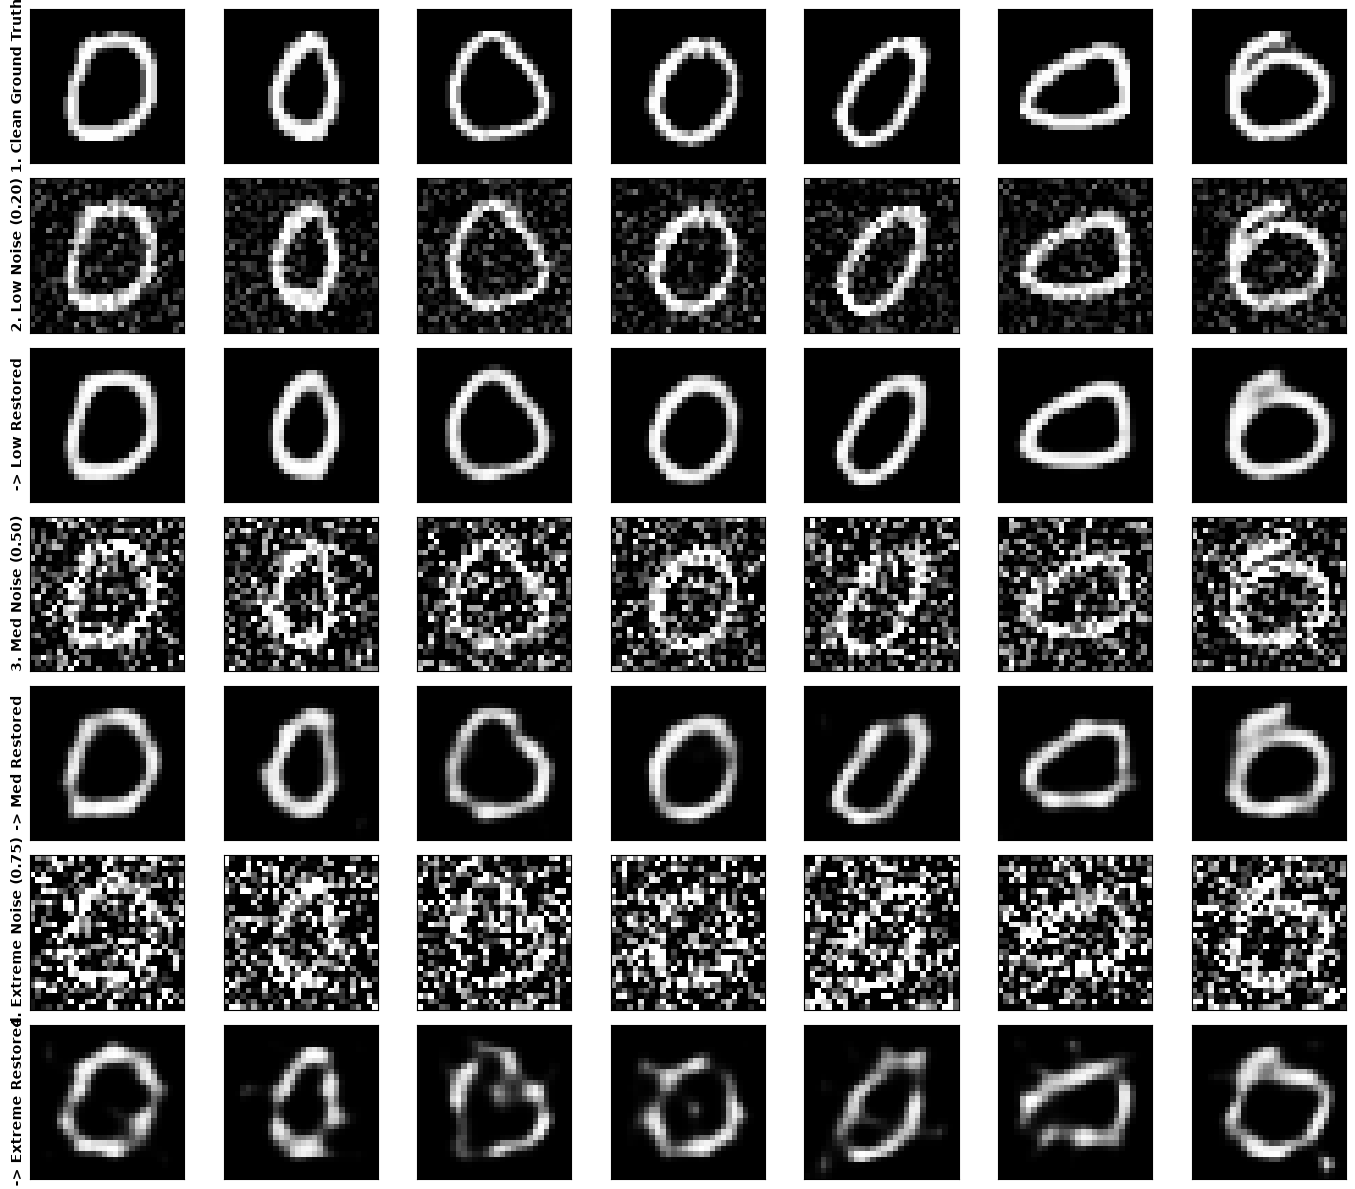

In [30]:
# Generate stress-test datasets at varying noise severities
test_low_noise = inject_gaussian_noise(test_clean_imgs, noise_factor=0.20)
test_med_noise = inject_gaussian_noise(test_clean_imgs, noise_factor=0.50)
test_ext_noise = inject_gaussian_noise(test_clean_imgs, noise_factor=0.75)

# Run inference using our model trained on 0.35 noise
pred_low = dae_model.predict(test_low_noise, batch_size=512, verbose=0)
pred_med = dae_model.predict(test_med_noise, batch_size=512, verbose=0)
pred_ext = dae_model.predict(test_ext_noise, batch_size=512, verbose=0)

def plot_stress_test(clean, low_n, low_p, med_n, med_p, ext_n, ext_p, num_digits=6):
    """
    Plots a 7-row grid demonstrating model resilience across increasing noise levels.
    """
    plt.figure(figsize=(14, 12))
    rows = ['1. Clean Ground Truth',
            '2. Low Noise (0.20)', '-> Low Restored',
            '3. Med Noise (0.50)', '-> Med Restored',
            '4. Extreme Noise (0.75)', '-> Extreme Restored']
    
    datasets = [clean, low_n, low_p, med_n, med_p, ext_n, ext_p]
    
    for r_idx, (label, data_arr) in enumerate(zip(rows, datasets)):
        for c_idx in range(num_digits):
            ax = plt.subplot(7, num_digits, r_idx * num_digits + c_idx + 1)
            plt.imshow(data_arr[c_idx].reshape(28, 28), cmap='gray')
            if c_idx == 0:
                plt.ylabel(label, fontsize=10, fontweight='bold')
            plt.xticks([])
            plt.yticks([])
            
    plt.tight_layout()
    plt.show()

plot_stress_test(test_clean_imgs, test_low_noise, pred_low, test_med_noise, pred_med, test_ext_noise, pred_ext, num_digits=7)

### Stress-Test Observations:
1. **Robust Generalization (`0.20` and `0.50` Noise)**: Even though the model was trained exclusively on `0.35` noise, it generalizes remarkably well to both lower and higher noise severities. At `0.50` noise, despite substantial background interference, the restored digits remain sharp and structurally accurate.
2. **Failure Threshold (`0.75` Extreme Noise)**: At `0.75` noise, the signal-to-noise ratio drops so low that many digit strokes are completely submerged in random static. While the autoencoder successfully filters out the background noise, we begin observing semantic confusion (for example, a heavily corrupted `3` might get reconstructed as an `8` or a generic rounded blob, and an obscured `1` might resemble a `7`). This highlights a fundamental boundary in unsupervised denoising: when input features are degraded beyond recognition, the model defaults to generating the most statistically probable structural prototype from its training distribution.

### Conclusion
This project demonstrated the effectiveness of Convolutional Denoising Autoencoders for image restoration. By combining 2D spatial convolutions, bottleneck feature compression, and binary crossentropy optimization, the model achieved robust noise suppression while preserving critical structural geometry, as verified through both qualitative visual inspections and quantitative PSNR/MSE metrics.